## Regresion Lineal

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#cargar los datos
df = pd.read_csv("ad_viz_plotval_data(2).csv") #dataframe de año 2022 PM2.5

df.head()

,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/02/2022,AQS,10030010,1,5.3,ug/m3 LC,29,"FAIRHOPE, Alabama",1,100.0,...,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,19300,"Daphne-Fairhope-Foley, AL",1,Alabama,3,Baldwin,30.497478,-87.880258
1,01/05/2022,AQS,10030010,1,8.6,ug/m3 LC,48,"FAIRHOPE, Alabama",1,100.0,...,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,19300,"Daphne-Fairhope-Foley, AL",1,Alabama,3,Baldwin,30.497478,-87.880258
2,01/08/2022,AQS,10030010,1,8.5,ug/m3 LC,47,"FAIRHOPE, Alabama",1,100.0,...,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,19300,"Daphne-Fairhope-Foley, AL",1,Alabama,3,Baldwin,30.497478,-87.880258
3,01/11/2022,AQS,10030010,1,3.7,ug/m3 LC,21,"FAIRHOPE, Alabama",1,100.0,...,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,19300,"Daphne-Fairhope-Foley, AL",1,Alabama,3,Baldwin,30.497478,-87.880258
4,01/14/2022,AQS,10030010,1,11.6,ug/m3 LC,56,"FAIRHOPE, Alabama",1,100.0,...,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,19300,"Daphne-Fairhope-Foley, AL",1,Alabama,3,Baldwin,30.497478,-87.880258


In [41]:
#exploracion de datos
print("Dimensiones del dataset:", df.shape)
print("\nCantidad de valores diferentes por columna:")
print(df.nunique())

Dimensiones del dataset: (115, 22)

Cantidad de valores diferentes por columna:
Date                              115
Source                              1
Site ID                             1
POC                                 1
Daily Mean PM2.5 Concentration     72
Units                               1
Daily AQI Value                    43
Local Site Name                     1
Daily Obs Count                     1
Percent Complete                    1
AQS Parameter Code                  1
AQS Parameter Description           1
Method Code                         1
Method Description                  1
CBSA Code                           1
CBSA Name                           1
State FIPS Code                     1
State                               1
County FIPS Code                    1
County                              1
Site Latitude                       1
Site Longitude                      1
dtype: int64


In [43]:
df[
    ['Daily Mean PM2.5 Concentration', 'Daily AQI Value']
].describe()

,Daily Mean PM2.5 Concentration,Daily AQI Value
count,115.000000,115.000000
mean,7.317391,38.269565
std,3.755236,13.915359
min,2.600000,14.000000
25%,4.850000,27.000000
50%,7.100000,39.000000
75%,8.650000,48.000000
max,33.600000,97.000000


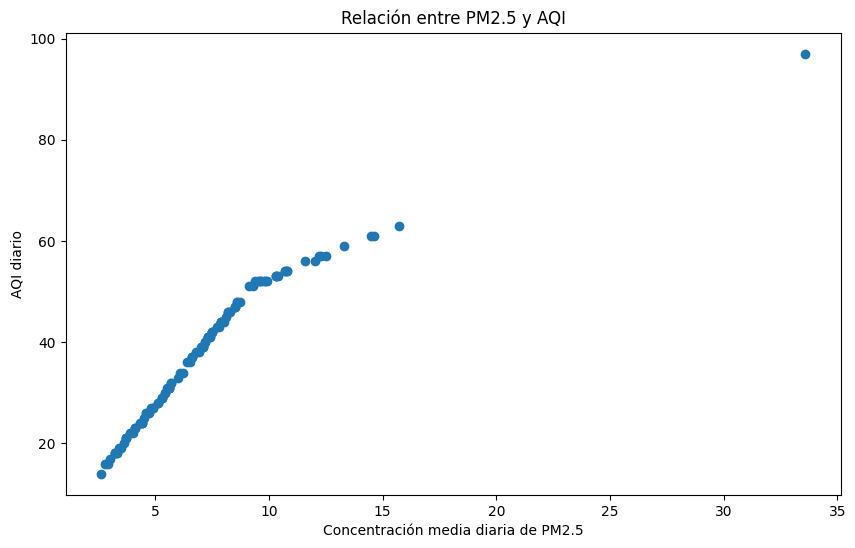

In [44]:
#Ver relación entre PM2.5 y AQI
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Daily Mean PM2.5 Concentration'],
    df['Daily AQI Value']
)

plt.xlabel("Concentración media diaria de PM2.5")
plt.ylabel("AQI diario")
plt.title("Relación entre PM2.5 y AQI")

plt.show()

In [24]:
# 1. Separar variables predictoras (X) y variable objetivo (y)
#Solo Compararemos Daily Mean PM2.5 Concentration y Daily AQI Value porque difieren en sus valores
#las demas columnas mantienen valores iguales
X = df[['Daily Mean PM2.5 Concentration']] #concentracion promedio diaria de PM2.5 - variable predictoria
y = df['Daily AQI Value'] #valor diaria del indice de Calidad de Aire - Variable objeto

In [25]:
print(df.columns) #revisar las columnas

Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'State FIPS Code', 'State', 'County FIPS Code', 'County',
       'Site Latitude', 'Site Longitude'],
      dtype='object')


In [26]:
#División de los datos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123
)

In [27]:
#regresión Lineal

modelo = LinearRegression()

modelo.fit(X_train, y_train)

LinearRegression()

In [28]:
print("Intercepto:", modelo.intercept_) #verificamos la intercepcion
print("Coeficiente:", modelo.coef_) #verificamos el modelo lineal

Intercepto: 13.577388889489217
Coeficiente: [3.34812851]


In [29]:
#predicciones

predicciones = modelo.predict(X_test)

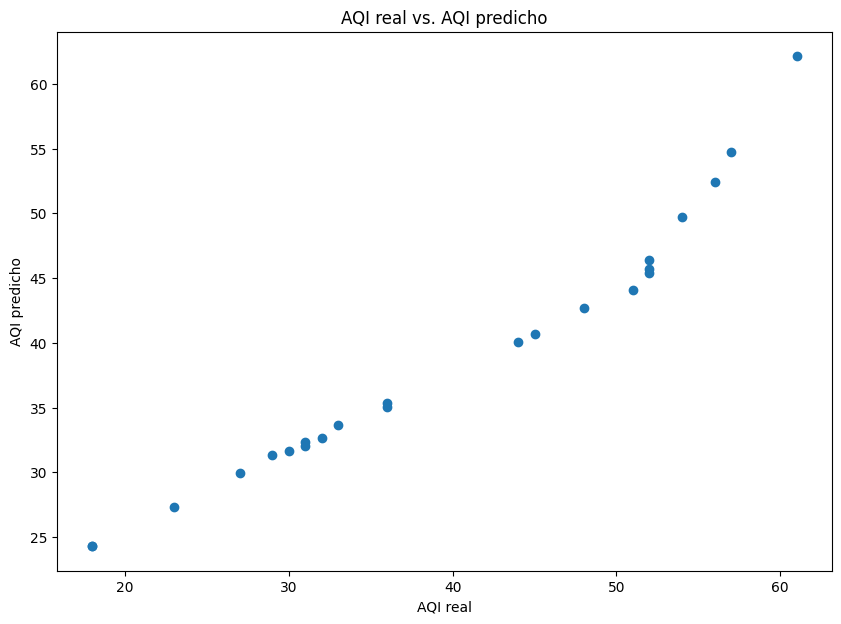

In [30]:
#valores reales vs. valores predichos

plt.figure(figsize=(10, 7))

plt.scatter(y_test, predicciones)

plt.xlabel("AQI real")
plt.ylabel("AQI predicho")
plt.title("AQI real vs. AQI predicho")

plt.show()

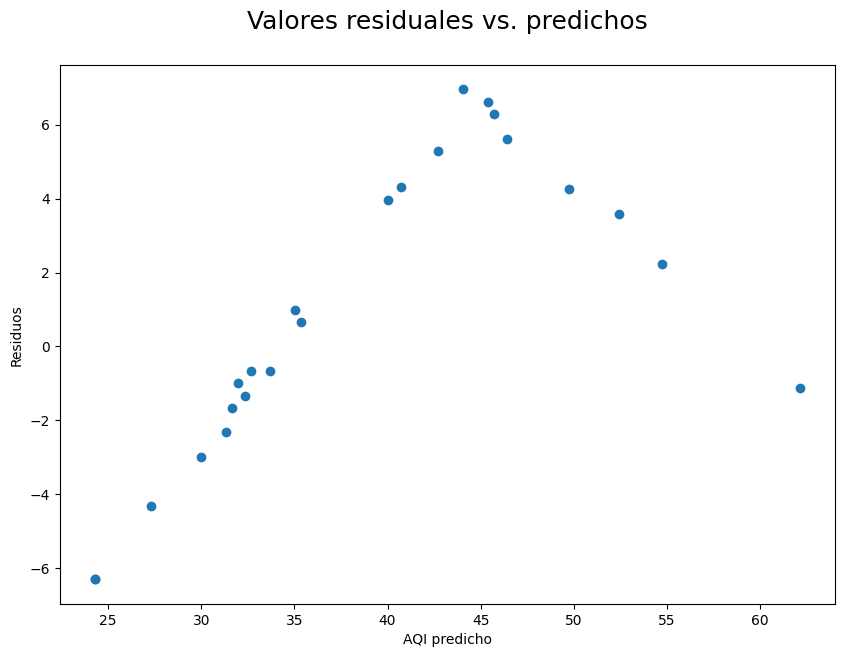

In [34]:
residuos = y_test - predicciones

plt.figure(figsize=(10, 7))

plt.scatter(predicciones, residuos)

plt.xlabel("AQI predicho")
plt.ylabel("Residuos")
plt.title("Valores residuales vs. predichos\n", fontsize = 18)

plt.show()

In [35]:
#evaluación

print("R²:", r2_score(y_test, predicciones))
print("MAE:", mean_absolute_error(y_test, predicciones))
print(
    "RMSE:",
    mean_squared_error(y_test, predicciones) ** 0.5
)

R²: 0.8991726819380966
MAE: 3.451973207284608
RMSE: 4.077876173482327


In [47]:
#probando por correlacion
correlacion = df[
    ['Daily Mean PM2.5 Concentration', 'Daily AQI Value']
].corr()

print(correlacion)


                                Daily Mean PM2.5 Concentration  \
Daily Mean PM2.5 Concentration                        1.000000   
Daily AQI Value                                       0.934874   

                                Daily AQI Value  
Daily Mean PM2.5 Concentration         0.934874  
Daily AQI Value                        1.000000  


In [48]:
#probando si la relacion es estadisticamente significativa minimos cuadrados

import statsmodels.api as sm
Xs = sm.add_constant(X)
stat_model = sm.OLS(y, Xs)
stat_result = stat_model.fit()
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:        Daily AQI Value   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     783.8
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.19e-52
Time:                        21:11:38   Log-Likelihood:                -346.36
No. Observations:                 115   AIC:                             696.7
Df Residuals:                     113   BIC:                             702.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       